Import libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

Read the data.

In [8]:
df = pd.read_csv("../Datasets/placement1.csv")
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


Scatterplot of data.

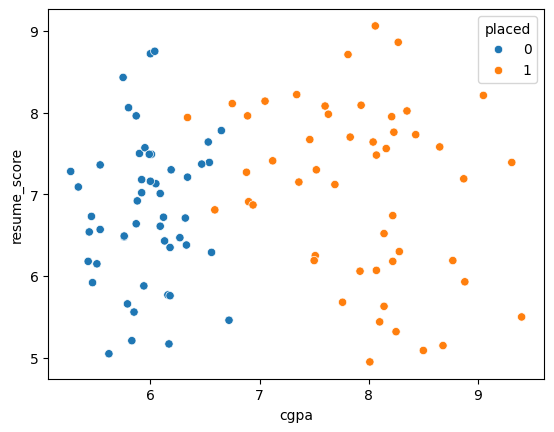

In [9]:
sns.scatterplot(x="cgpa", y="resume_score", hue="placed", data=df)
plt.show()

In [10]:
x = df[["cgpa", "resume_score"]]
y = df["placed"]

Perceptron function made by scikit.

In [11]:
from sklearn.linear_model import Perceptron
per = Perceptron()
per.fit(x, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


Values of a,b,c (m and b) for y = mx+b.

In [12]:
per.coef_, per.intercept_

(array([[ 40.26, -36.  ]]), array([-25.]))

Decision regions of the perceptron.

/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


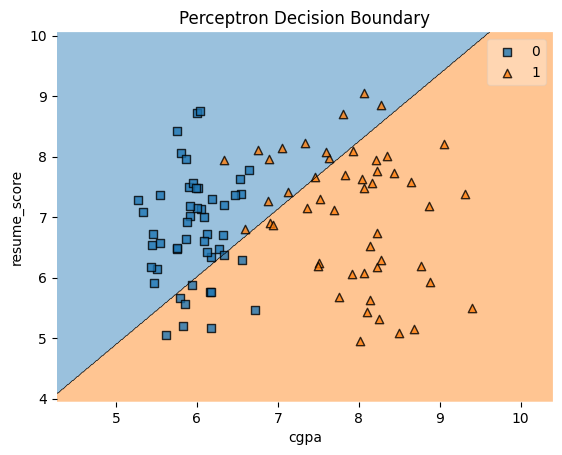

In [13]:
plot_decision_regions(x.values, y.values, clf=per)
plt.xlabel("cgpa")
plt.ylabel("resume_score")
plt.title("Perceptron Decision Boundary")
plt.show()

Another dataset.

In [14]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

Scatterplot of the data.

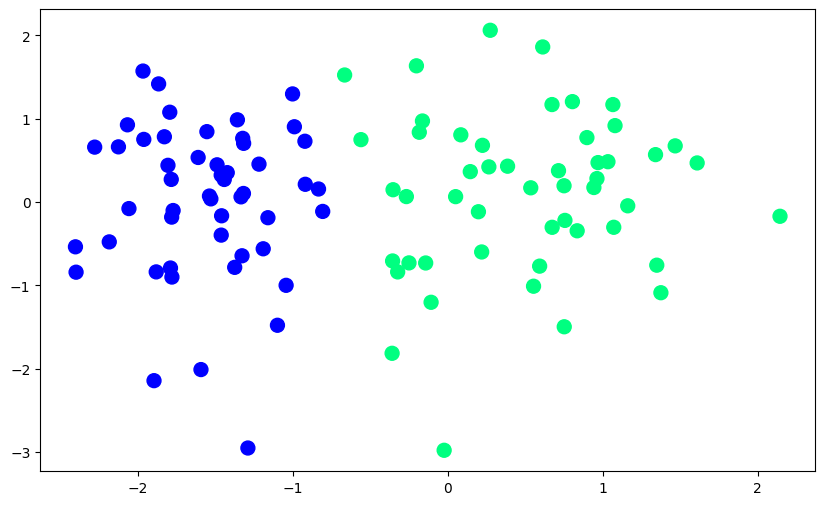

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

Function for y_cap.

In [19]:
def step(z):
    return 1 if z>0 else 0

Funtion for perceptron ( best fit line).

In [20]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]
        

Print the a,b,c for trained perceptron.

In [21]:
intercept_,coef_ = perceptron(X,y)
print(coef_)
print(intercept_)

[1.35004439 0.07765244]
1.0


Calculate the m and b.

In [22]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [23]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

Plot the points and the best fit line according to our function.

(-3.0, 2.0)

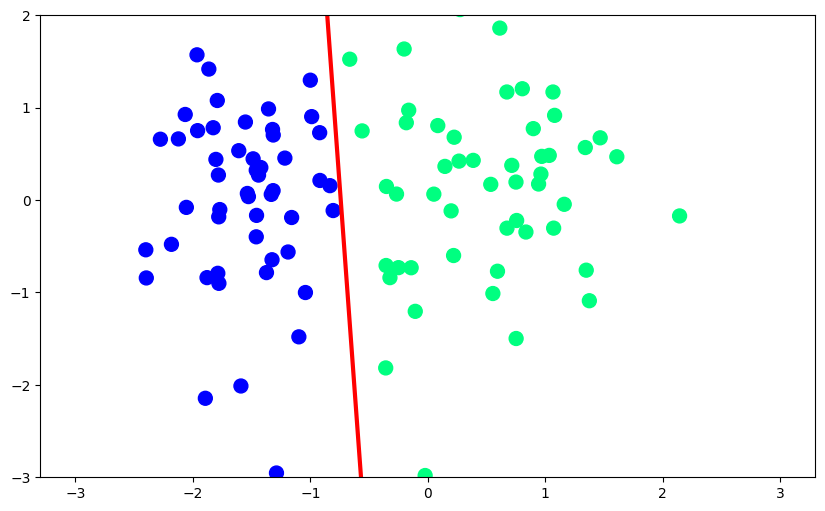

In [24]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)